In [253]:
import numpy as np
from mpi4py import MPI
from basix.ufl import element
from dolfinx import mesh, fem, io, plot
from ufl import TrialFunction, TestFunction, dx

import pyvista
import ufl
from pathlib import Path
from dolfinx.fem.petsc import LinearProblem

from dolfinx import *

In [ ]:
# Create mesh and define function space
y_lim = 1.0
x_lim = 1.0

domain = mesh.create_rectangle(MPI.COMM_WORLD, ((0,0),(x_lim, y_lim)), [128, 128])
V = fem.functionspace(domain, element("CG", domain.basix_cell(), 1))

# Parameters
D_phys = fem.Constant(domain, 2.1e-5)
theta = fem.Constant(domain, 1.0)
Pe = fem.Constant(domain, 1e2)
t_end = 10 
dt = 0.1

In [255]:
def velocity_field(x):
    return np.vstack((np.ones_like(x[0]), np.ones_like(x[1])))

u0 = fem.Function(V)
u0.x.array[:] = 0.0

inlet_y_start = y_lim / 2 - 0.05 * y_lim
inlet_y_end = y_lim / 2 + 0.05 * y_lim

u_inlet = fem.Constant(domain, 1.0)

def boundary_inlet(x):
    return np.isclose(x[0], 0.0) & (x[1] > inlet_y_start) & (x[1] < inlet_y_end)

V_vec = fem.functionspace(domain, ("CG", 1, (domain.geometry.dim,)))
beta = fem.Function(V_vec)
beta.interpolate(velocity_field)

def boundary_all_except_inlet(x):
    all = np.isclose(x[0], 0.0) | np.isclose(x[0], x_lim) | \
          np.isclose(x[1], 0.0) | np.isclose(x[1], y_lim)
    
    return all & ~boundary_inlet(x)

u_zero = fem.Constant(domain, 0.0)
bc_zero = fem.dirichletbc(u_zero, fem.locate_dofs_geometrical(V, boundary_all_except_inlet), V)

u_one = fem.Constant(domain, 1.0)
bc_inlet = fem.dirichletbc(u_one, fem.locate_dofs_geometrical(V, boundary_inlet), V)

In [256]:
U_char = ufl.sqrt(ufl.dot(beta, beta))
h = ufl.CellDiameter(domain)
#Pe = U_char * h / D_phys
nb = ufl.sqrt(ufl.inner(beta, beta))

tau = 0.5 * h * pow(4.0 / (Pe*h) + 2.0 * nb, -1.0)

In [257]:
v = TestFunction(V)
u = TrialFunction(V)

A1 = (1.0/Pe) * ufl.inner(ufl.grad(u), ufl.grad(v)) * dx + \
     ufl.inner(beta, ufl.grad(u)) * v * dx

A0 = (1.0/Pe) * ufl.inner(ufl.grad(u0), ufl.grad(v)) * dx + \
     ufl.inner(beta, ufl.grad(u0)) * v * dx

A = (1/dt)*ufl.inner(u, v) * dx - (1/dt)* ufl.inner(u0,v) * dx + theta* A1 + (1-theta) * A0

r=(((1/dt)*(u-u0) + theta*((1.0/Pe)* ufl.div(ufl.grad(u)) + ufl.inner(beta,ufl.grad(u))) + 
   (1-theta)*((1.0/Pe)*ufl.div(ufl.grad(u0)) + ufl.inner(beta,ufl.grad(u0))) ) * 
  tau * ufl.inner(beta,ufl.grad(v))*dx)

F = A + r

In [258]:
problem = LinearProblem(ufl.lhs(F), ufl.rhs(F), bcs=[bc_zero, bc_inlet], petsc_options={"ksp_type": "gmres", "pc_type": "ilu"})
u = fem.Function(V)

xdmf = io.XDMFFile(domain.comm, "results.xdmf", "w")
xdmf.write_mesh(domain)

t = 0.10 von 10.00
t = 0.20 von 10.00
t = 0.30 von 10.00
t = 0.40 von 10.00
t = 0.50 von 10.00
t = 0.60 von 10.00
t = 0.70 von 10.00
t = 0.80 von 10.00
t = 0.90 von 10.00
t = 1.00 von 10.00
t = 1.10 von 10.00
t = 1.20 von 10.00
t = 1.30 von 10.00
t = 1.40 von 10.00
t = 1.50 von 10.00
t = 1.60 von 10.00
t = 1.70 von 10.00
t = 1.80 von 10.00
t = 1.90 von 10.00
t = 2.00 von 10.00
t = 2.10 von 10.00
t = 2.20 von 10.00
t = 2.30 von 10.00
t = 2.40 von 10.00
t = 2.50 von 10.00
t = 2.60 von 10.00
t = 2.70 von 10.00
t = 2.80 von 10.00
t = 2.90 von 10.00
t = 3.00 von 10.00
t = 3.10 von 10.00
t = 3.20 von 10.00
t = 3.30 von 10.00
t = 3.40 von 10.00
t = 3.50 von 10.00
t = 3.60 von 10.00
t = 3.70 von 10.00
t = 3.80 von 10.00
t = 3.90 von 10.00
t = 4.00 von 10.00
t = 4.10 von 10.00
t = 4.20 von 10.00
t = 4.30 von 10.00
t = 4.40 von 10.00
t = 4.50 von 10.00
t = 4.60 von 10.00
t = 4.70 von 10.00
t = 4.80 von 10.00
t = 4.90 von 10.00
t = 5.00 von 10.00
t = 5.10 von 10.00
t = 5.20 von 10.00
t = 5.30 von

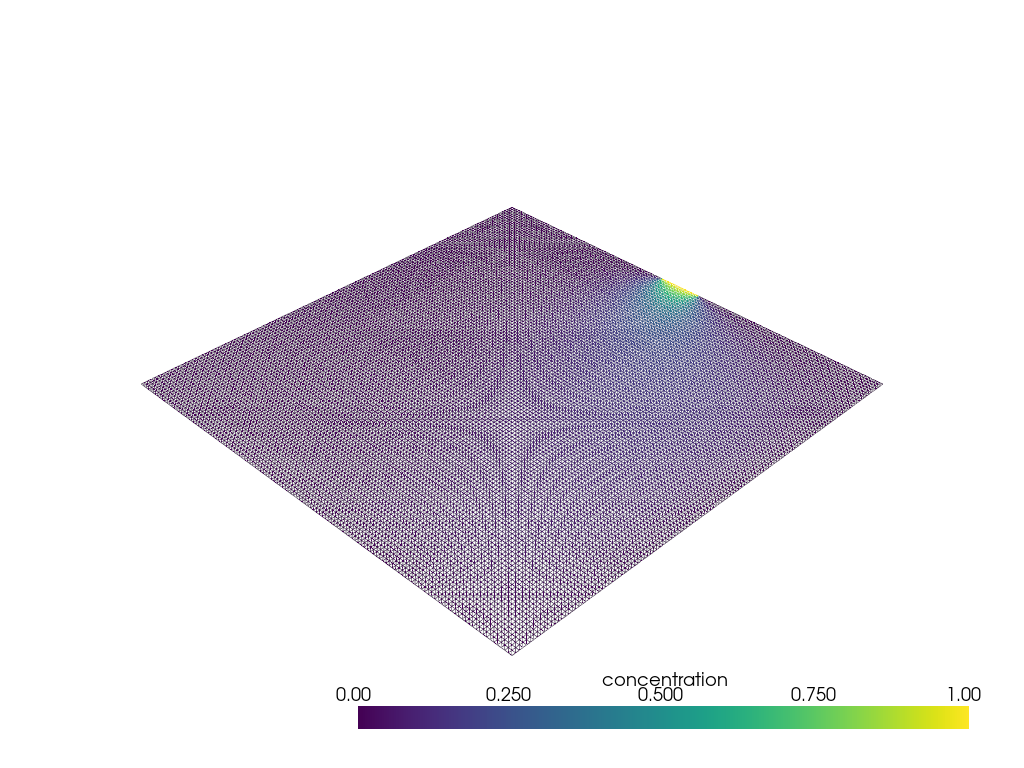

In [259]:
t = 0.0
u.x.array[:] = u0.x.array

while t < t_end:
    t += dt
    print(f"t = {t:.2f} von {t_end:.2f}")

    u = problem.solve()
    xdmf.write_function(u, t)
    u0.x.array[:] = u.x.array

xdmf.close()

domain.topology.create_entities(1)
domain.topology.create_connectivity(1, 2)
topology, cell_type, geometry = plot.vtk_mesh(domain, 1)
grid = pyvista.UnstructuredGrid(topology, cell_type, geometry)
grid.point_data["concentration"] = u.x.array.real
plotter = pyvista.Plotter()
plotter.add_mesh(grid, show_edges=True)
plotter.show()